### hand-off의 개념과 command 사용법 익히기

In [1]:
!uv --version

uv 0.12.17 (635500036 2026-09-18 x86_64-pc-windows-msvc)


In [3]:
from typing import Literal
from langgraph.types import Command
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import AIMessage

def agent_1(state: MessagesState) -> Command[Literal["agent_2"]]:
    messages = AIMessage(content="1번 에이전트 메시지입니다.")
    return Command(
        goto="agent_2",
        update={"messages": [messages]}
    )

def agent_2(state: MessagesState) -> Command[Literal[END]]:
    message = AIMessage(content="2번 에이전트 메시지입니다.")
    return Command(
        goto=END,
        update={"messages": [message]}
    )

graph_builder = StateGraph(MessagesState)
graph_builder.add_node("agent_1", agent_1)
graph_builder.add_node("agent_2", agent_2)

graph_builder.add_edge(START, "agent_1")

graph = graph_builder.compile()

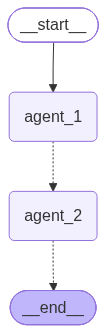

In [4]:
graph

In [5]:
for chunk in graph.stream({"messages" : []}, stream_mode="values"):
    print(chunk)

{'messages': []}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='8d2d101e-f285-4848-aca2-e4ec33ada665', tool_calls=[], invalid_tool_calls=[])]}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='8d2d101e-f285-4848-aca2-e4ec33ada665', tool_calls=[], invalid_tool_calls=[]), AIMessage(content='2번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='1dbae4eb-efad-4a9e-af6c-34d1100ca1e8', tool_calls=[], invalid_tool_calls=[])]}


In [6]:
from typing import Literal
from langgraph.types import Command
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import AIMessage

class State(MessagesState):
    foo: str

def agent_1(state: State) -> Command[Literal["agent_2", "agent_3"]]:
    messages = AIMessage(content="1번 에이전트 메시지입니다.")
    if state["foo"] == "bar":
        return Command(
            goto="agent_3",
            update={"messages": [messages], "foo": "baz"}
        )
    return Command(
        goto="agent_2",
        update={"messages": [messages]}
    )

def agent_2(state: State):
    message = AIMessage(content="2번 에이전트 메시지입니다.")
    return Command(
        goto=END,
        update={"messages": [message]}
    )

def agent_3(state: State):
    message = AIMessage(content="3번 에이전트 메시지입니다.")
    return Command(
        goto=END,
        update={"messages": [message]}
    )

graph_builder = StateGraph(State)
graph_builder.add_node("agent_1", agent_1)
graph_builder.add_node("agent_2", agent_2)
graph_builder.add_node("agent_3", agent_3)

graph_builder.add_edge(START, "agent_1")

graph = graph_builder.compile()

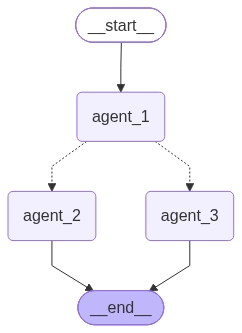

In [7]:
graph

In [8]:
for chunk in graph.stream({"messages": [], "foo": "bar"}, stream_mode="values"):
    print(chunk)

{'messages': [], 'foo': 'bar'}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='145a7f18-f09a-4545-bbb3-8cec42216efb', tool_calls=[], invalid_tool_calls=[])], 'foo': 'baz'}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='145a7f18-f09a-4545-bbb3-8cec42216efb', tool_calls=[], invalid_tool_calls=[]), AIMessage(content='3번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='3b1bfa79-d9ff-42d4-8735-8871eee0afbd', tool_calls=[], invalid_tool_calls=[])], 'foo': 'baz'}


In [9]:
for chunk in graph.stream({"messages": [], "foo": "baz"}, stream_mode="values"):
    print(chunk)

{'messages': [], 'foo': 'baz'}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='84884cf9-0f9b-4972-b67c-654211d1dfae', tool_calls=[], invalid_tool_calls=[])], 'foo': 'baz'}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='84884cf9-0f9b-4972-b67c-654211d1dfae', tool_calls=[], invalid_tool_calls=[]), AIMessage(content='2번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='57228620-7c8f-46d8-b43d-57f7c4842b52', tool_calls=[], invalid_tool_calls=[])], 'foo': 'baz'}
